# 00. 수집·탐색 — 데이터는 어떻게 확보했고, 그 실체는 무엇인가

**이 장의 질문**: 우리는 무엇을, 어디서, 어떤 근거로 가져왔는가. 그리고 그 데이터의
실체(스키마·품질·정합성·한계)는 EDA에 들어가기 전에 무엇을 말해주는가.

이 장은 c2 사이클에서 신설되었습니다. c1에서는 수집이 01장 서두에 코드 몇 줄로
압축되어 있었고, 탐색 없이 곧바로 EDA(분포·기저율 분석)로 진입했습니다. c2는
**수집의 서사**(왜 이 출처인가, 어떻게 가져왔는가)와 **탐색**(데이터 실체의 전수
확인)을 독립 단계로 분리합니다 — EDA는 "데이터가 무엇을 말하는가"를 묻지만,
탐색은 그 전에 "데이터가 무엇인가"부터 확인합니다.

## 개정 이력 (반복 사이클 규약 — 정본: [ITERATION-LOG](ITERATION-LOG.md))

| 사이클 | 날짜 | 발견 | 원인 | 수정 | 영향 범위 |
|---|---|---|---|---|---|
| c2 | 2026-07-23 | ① 수집 서사·탐색 단계 부재 ② Elo 입력이 월드컵 한정(4년 주기 희소)이라 공백 감쇠(FT-R7)가 증상 처치에 그침 | 노트북_서사 v1.0의 9장 선형 구조에 "탐색"·"반복" 관점 부재 | 00장 신설 · 실명 마스킹 경계를 이 장으로 이동 · 2차 출처(martj42, CC0) 채택으로 Elo 입력을 전체 남자 A매치로 확장 | 01·02장 보강, 기획서 10절 Elo 수치 갱신 |

In [1]:
# 환경·시드 고정 (재현 규약 — 노트북_서사 §5)
import sys, platform, random, hashlib, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import missingno as msno
import pandera as pa

SEED = 42
random.seed(SEED); np.random.seed(SEED)

matplotlib.rcParams["font.family"] = ["Pretendard", "Malgun Gothic", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw"          # 불변 원본 (절대 수정 금지 — ccds 규약)
DATA_INTERIM = ROOT / "data" / "interim"  # 마스킹·정제 산출물
FIGURES = ROOT / "notebooks" / "figures"
for d in (DATA_RAW, DATA_INTERIM, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

print(f"Python {sys.version.split()[0]} on {platform.system()}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"missingno {msno.__version__} | pandera {pa.__version__}")
print(f"SEED = {SEED} | ROOT = {ROOT.name}")

Python 3.12.13 on Windows
pandas 3.0.3 | numpy 1.26.4 | matplotlib 3.10.9
missingno 0.5.2 | pandera 0.32.1
SEED = 42 | ROOT = data-analysis-notebook-improve-98b328


## 1. 수집 — 출처 선정의 이유 (P2 → P10 역추적)

**1차 출처 — [jfjelstul/worldcup](https://github.com/jfjelstul/worldcup)** (CC BY-SA 4.0):
후보 데이터셋 감사(P2)에서 ① 1차 출처(재업로드가 아닌 저작자 직접 배포) ② 라이선스
명시(CC BY-SA 4.0) ③ 월드컵 전 대회 커버리지를 근거로 채택했습니다. 경쟁 후보였던
StatsBomb 재업로드 데이터셋들은 P10에서 **카드 표기("CC BY-SA")와 원 계약(비상업·
재배포 금지)의 문구 단위 불일치**가 확인되어 기각했습니다. 파생 산출물의 고지 의무는
[DATA-LICENSE.md](../DATA-LICENSE.md)에 명문화되어 있습니다.

**2차 출처 — [martj42/international_results](https://github.com/martj42/international_results)**
(CC0 1.0, c2 채택): c1의 Elo는 월드컵 경기(4년 주기)만 입력으로 사용해 대회 사이의
레이팅 공백을 감쇠 파라미터(FT-R7)로 보정해야 했습니다. 이 데이터셋은 1872년 이후
전체 남자 A매치 결과를 담고 있어 **공백 자체를 구조적으로 줄입니다** (근거: P18 Q4).
`results.csv`에는 선수명 컬럼이 없으며, 선수 실명이 포함된 `goalscorers.csv`는
**다운로드 자체를 하지 않습니다** — 실명 파일이 로컬에 생기지 않게 하는 구조적 차단입니다.

**수집 규약 (c2 신설)**:
1. **커밋 핀 고정** — `master` 브랜치가 아닌 특정 커밋 SHA의 원본을 받습니다.
   데이터 레포가 갱신되어도 우리 파이프라인의 입력은 불변 → 재현성(NB-R3)
2. **불변 원본** — `data/raw/`의 파일은 절대 수정하지 않습니다. 모든 가공은
   `data/interim/` 이후에서만 (cookiecutter-data-science 규약, P18 Q5)
3. **체크섬 기록** — 파일별 SHA-256을 기록해 "우리가 분석한 그 파일"을 증명합니다

In [2]:
# 수집 대상과 커밋 핀 (2026-07-23 gh api로 조회한 각 레포의 HEAD)
PIN_JFJELSTUL = "35a8667f518b07469182ae16d35574dd0e7a00fb"
PIN_MARTJ42 = "a16ff3edb297bda95d0ed02d5fc0c1ecb5b1c1cf"

SOURCES = {
    # (레포, 커밋 핀, 레포 내 경로 템플릿, 저장 하위 폴더)
    "jfjelstul": ("jfjelstul/worldcup", PIN_JFJELSTUL, "data-csv/{name}.csv"),
    "martj42": ("martj42/international_results", PIN_MARTJ42, "{name}.csv"),
}
FILES = {
    "jfjelstul": ["matches", "team_appearances", "tournaments", "goals"],
    "martj42": ["results"],  # goalscorers.csv는 실명 포함 — 수집 대상에서 구조적으로 제외
}

def fetch_pinned(source: str, name: str) -> Path:
    """커밋 핀 고정 다운로드 (캐시 우선 — raw는 불변이므로 존재하면 재사용)"""
    repo, pin, tmpl = SOURCES[source]
    dest = DATA_RAW / source / f"{name}.csv"
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    url = f"https://raw.githubusercontent.com/{repo}/{pin}/" + tmpl.format(name=name)
    with urllib.request.urlopen(url, timeout=120) as r:
        dest.write_bytes(r.read())
    return dest

collect_rows = []
paths: dict[tuple, Path] = {}
for source, names in FILES.items():
    for name in names:
        p = fetch_pinned(source, name)
        paths[(source, name)] = p
        collect_rows.append({
            "출처": source, "파일": f"{name}.csv",
            "크기(bytes)": p.stat().st_size,
            "SHA-256(앞 12)": hashlib.sha256(p.read_bytes()).hexdigest()[:12],
            "커밋 핀": SOURCES[source][1][:10],
        })
collect_log = pd.DataFrame(collect_rows)
print("수집 완료 — 핀 고정·체크섬 대장:")
collect_log

수집 완료 — 핀 고정·체크섬 대장:


,출처,파일,크기(bytes),SHA-256(앞 12),커밋 핀
0,jfjelstul,matches.csv,298930,037f71876475,35a8667f51
1,jfjelstul,team_appearances.csv,557506,10daa0692911,35a8667f51
2,jfjelstul,tournaments.csv,3287,906b122d80aa,35a8667f51
3,jfjelstul,goals.csv,734494,4fbe990b7f42,35a8667f51
4,martj42,results.csv,3727748,9bc66b3829f3,a16ff3edb2


## 2. 실명 마스킹 — NB-R1 경계 (c2에서 01장으로부터 이동)

커밋되는 노트북은 공개 문서이므로 선수 실명은 출력 셀에조차 나타나면 안 됩니다
(P7 퍼블리시티권 경계). c1에서는 이 경계가 01장 서두에 있었지만, **00장이 원본을
만지는 첫 지점이 된 이상 경계도 여기로 앞당깁니다** — 이후의 프로파일 요약이 컬럼
값 샘플을 노출하기 때문에, 마스킹 이전 데이터에 프로파일링을 돌리면 실명이 새어
나갈 수 있습니다(P18 Q1 채택 조건 1).

방식은 c1과 동일한 **구조의 방어**입니다: 로드 직후 실명 계열 컬럼을 drop하고 원본
변수를 `del` — "조심한다"(주의력)가 아니라 "변수가 존재하지 않는다"(구조)로 막습니다.
마스킹된 테이블은 `data/interim/`에 저장되며, **01장 이후는 interim만 읽습니다.**

In [3]:
NAME_KEYS = ("given_name", "family_name", "player_name", "full_name", "shirt_name")

def mask_and_save(source: str, name: str) -> pd.DataFrame:
    """로드 → 실명 컬럼 drop → interim 저장. 반환: 마스킹된 프레임"""
    _raw = pd.read_csv(paths[(source, name)])
    dropped = [c for c in _raw.columns if any(k in c.lower() for k in NAME_KEYS)]
    df = _raw.drop(columns=dropped)
    del _raw  # 원본 변수 삭제 — 이후 셀에서 실명 접근 불가
    # 게이트: 남은 컬럼에 실명 계열이 없어야 한다
    assert not any(any(k in c.lower() for k in NAME_KEYS) for c in df.columns), name
    df.to_parquet(DATA_INTERIM / f"{source}_{name}.parquet")
    if dropped:
        print(f"  {source}/{name}: 실명 컬럼 {len(dropped)}개 제거 → {dropped}")
    else:
        print(f"  {source}/{name}: 실명 컬럼 0개 (원래 없음 — 검사로 확인)")
    return df

tables: dict[str, pd.DataFrame] = {}
for source, names in FILES.items():
    for name in names:
        tables[name] = mask_and_save(source, name)

# martj42 채택 전제의 재확인: results.csv에는 선수 식별 정보가 없다
assert not any("player" in c.lower() or "scorer" in c.lower() for c in tables["results"].columns)
print("\n마스킹 게이트 통과 — 메모리·interim 모두 실명 컬럼 0개")
print(f"interim 산출물: {sorted(p.name for p in DATA_INTERIM.glob('*.parquet'))}")

  jfjelstul/matches: 실명 컬럼 0개 (원래 없음 — 검사로 확인)
  jfjelstul/team_appearances: 실명 컬럼 0개 (원래 없음 — 검사로 확인)
  jfjelstul/tournaments: 실명 컬럼 0개 (원래 없음 — 검사로 확인)
  jfjelstul/goals: 실명 컬럼 2개 제거 → ['family_name', 'given_name']


  martj42/results: 실명 컬럼 0개 (원래 없음 — 검사로 확인)

마스킹 게이트 통과 — 메모리·interim 모두 실명 컬럼 0개
interim 산출물: ['jfjelstul_goals.parquet', 'jfjelstul_matches.parquet', 'jfjelstul_team_appearances.parquet', 'jfjelstul_tournaments.parquet', 'martj42_results.parquet', 'team_name_map.parquet']


## 3. 탐색 (1) — 테이블 전수 조사

각 테이블이 "무엇인지"부터 확인합니다: 규모(행·컬럼·메모리), 타입 구성, 키 후보의
유일성. **키 유일성은 이후 모든 조인의 전제**이므로 여기서 깨지면 하류 전체가 무효입니다.

In [4]:
KEY_CANDIDATES = {
    "matches": ["match_id"],
    "team_appearances": ["match_id", "team_id"],   # 복합키
    "tournaments": ["tournament_id"],
    "goals": ["goal_id"],
    "results": ["date", "home_team", "away_team"],  # 복합키 (동일 대진 동일 날짜 중복 여부)
}

overview_rows = []
for name, df in tables.items():
    keys = KEY_CANDIDATES[name]
    n_dup = df.duplicated(subset=keys).sum()
    overview_rows.append({
        "테이블": name, "행": len(df), "컬럼": df.shape[1],
        "메모리(KB)": round(df.memory_usage(deep=True).sum() / 1024),
        "수치형": df.select_dtypes("number").shape[1],
        "키 후보": "+".join(keys), "키 중복": int(n_dup),
    })
overview = pd.DataFrame(overview_rows)

# 게이트 — 조인에 쓰이는 jfjelstul 키는 엄격히 유일해야 한다
jf_dup = overview[overview["테이블"] != "results"]["키 중복"]
assert (jf_dup == 0).all(), "조인 키 유일성 위반 — 하류 조인 전제가 깨짐"
print("조인 키 유일성: jfjelstul 4테이블 통과 (중복 0)")

# results의 (date, home, away)는 진짜 키가 아니다 — 첫 실행이 잡아낸 사실:
# 1974-02-17 타히티-뉴칼레도니아가 같은 날 2경기(더블헤더, 2-1과 1-2)로 실존한다.
# 데이터 오류가 아닌 실제 역사이며, Elo 산출은 행 단위 순차 처리라 조인 키가
# 필요 없다 → 두 행 모두 유효 입력으로 유지 (조용한 중복 제거 금지)
res_dup = tables["results"][tables["results"].duplicated(
    subset=KEY_CANDIDATES["results"], keep=False)]
if len(res_dup):
    print(f"\nresults 동일 (날짜,대진) 중복 {len(res_dup)}행 — 실제 더블헤더로 판정, 유지:")
    print(res_dup.to_string(index=False))
overview

조인 키 유일성: jfjelstul 4테이블 통과 (중복 0)

results 동일 (날짜,대진) 중복 2행 — 실제 더블헤더로 판정, 유지:
      date home_team     away_team  home_score  away_score tournament    city country  neutral
1974-02-17    Tahiti New Caledonia           2           1   Friendly Papeete  Tahiti    False
1974-02-17    Tahiti New Caledonia           1           2   Friendly Papeete  Tahiti    False


,테이블,행,컬럼,메모리(KB),수치형,키 후보,키 중복
0,matches,1248,37,584,16,match_id,0
1,team_appearances,2496,36,1110,17,match_id+team_id,0
2,tournaments,30,18,6,12,tournament_id,0
3,goals,3637,25,1239,8,goal_id,0
4,results,49520,9,6022,2,date+home_team+away_team,1


## 4. 탐색 (2) — 스키마·정합성의 기계 검증 (pandera — 이후 전 장 게이트의 원형)

c1의 리키지 assert(02장)를 일반화합니다: 각 장의 입력이 지켜야 할 계약을
**pandera 스키마**로 선언하고, 위반 시 명시적 에러로 중단합니다(NB-R5의 도구화).
여기서는 핵심 두 테이블(matches·results)의 계약과 테이블 간 참조 정합(FK)을 검증합니다.

In [5]:
# (1) 핵심 컬럼 계약 — 득점은 0 이상, 팀·날짜는 비결측
schema_matches = pa.DataFrameSchema({
    "match_id": pa.Column(nullable=False),
    "match_date": pa.Column(nullable=False),
    "home_team_score": pa.Column(checks=pa.Check.ge(0), nullable=False, coerce=False),
    "away_team_score": pa.Column(checks=pa.Check.ge(0), nullable=False, coerce=False),
})
schema_results = pa.DataFrameSchema({
    "date": pa.Column(nullable=False),
    "home_team": pa.Column(nullable=False),
    "away_team": pa.Column(nullable=False),
    "home_score": pa.Column(checks=pa.Check.ge(0), nullable=False),
    "away_score": pa.Column(checks=pa.Check.ge(0), nullable=False),
})
schema_matches.validate(tables["matches"], lazy=True)
schema_results.validate(tables["results"], lazy=True)
print("pandera 스키마 검증 통과 — matches·results 핵심 계약 위반 0건")

# (2) 테이블 간 참조 정합 (FK) — 고아 레코드 검사
fk_checks = [
    ("matches.tournament_id ⊆ tournaments", tables["matches"]["tournament_id"], tables["tournaments"]["tournament_id"]),
    ("goals.match_id ⊆ matches", tables["goals"]["match_id"], tables["matches"]["match_id"]),
    ("team_appearances.match_id ⊆ matches", tables["team_appearances"]["match_id"], tables["matches"]["match_id"]),
]
for label, child, parent in fk_checks:
    orphan = ~child.isin(set(parent))
    assert not orphan.any(), f"{label}: 고아 {orphan.sum()}건"
    print(f"FK 정합 통과: {label} (고아 0건)")

pandera 스키마 검증 통과 — matches·results 핵심 계약 위반 0건
FK 정합 통과: matches.tournament_id ⊆ tournaments (고아 0건)
FK 정합 통과: goals.match_id ⊆ matches (고아 0건)
FK 정합 통과: team_appearances.match_id ⊆ matches (고아 0건)


C:\Users\kik32\anaconda3\Lib\site-packages\pandera\_pandas_deprecated.py:144: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


## 5. 탐색 (3) — 결측 구조: "얼마나"가 아니라 "어디에·왜"

결측률 수치만으로는 처리 방침을 정할 수 없습니다. 결측이 **특정 시대·특정 컬럼군에
몰려 있는지**(구조적 결측)를 시각적으로 확인해야 "버릴 컬럼 / 채울 컬럼 / 그대로 둘
컬럼"의 근거가 생깁니다. 이 판단은 01장의 전처리 결정 절로 넘깁니다.

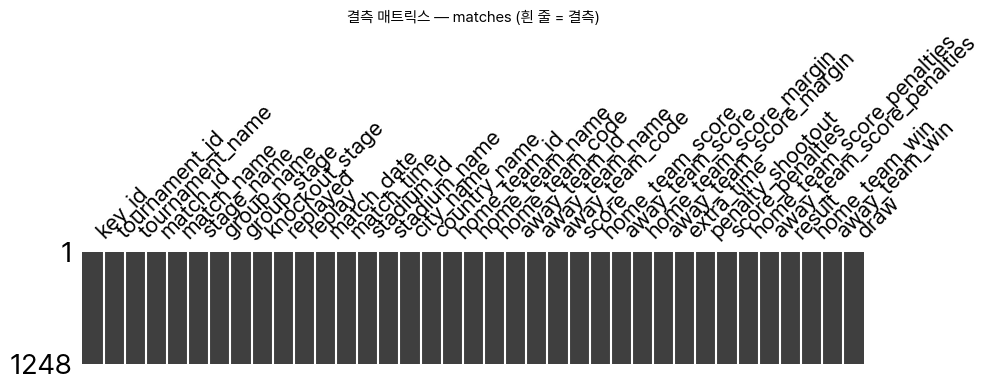

저장: notebooks\figures\00_missing_matches.png


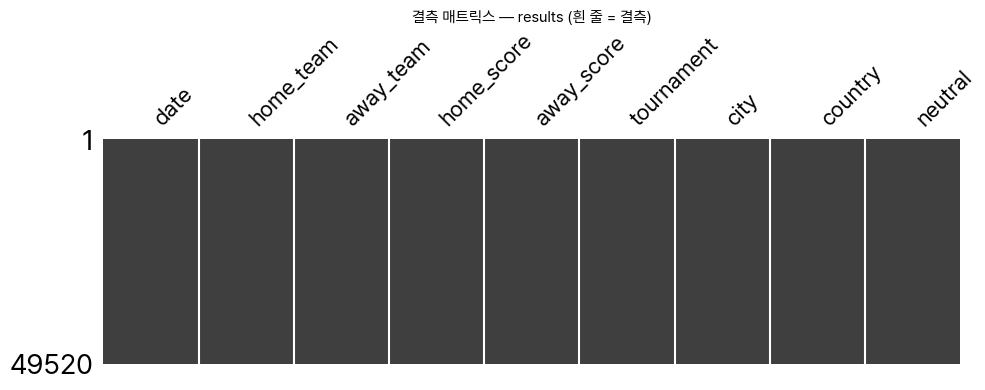

저장: notebooks\figures\00_missing_results.png
matches: 결측 보유 컬럼 0/37개
results: 결측 보유 컬럼 0/9개


,,결측률(%)
테이블,컬럼,


In [6]:
def missing_table(df: pd.DataFrame, name: str, top: int = 12) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"{name}: 결측 보유 컬럼 {len(miss)}/{df.shape[1]}개")
    return (miss.head(top) * 100).round(2).rename("결측률(%)").to_frame()

for name in ("matches", "results"):
    fig_path = FIGURES / f"00_missing_{name}.png"
    ax = msno.matrix(tables[name], figsize=(10, 4), sparkline=False)
    ax.set_title(f"결측 매트릭스 — {name} (흰 줄 = 결측)", fontsize=11)
    plt.tight_layout(); plt.savefig(fig_path, dpi=120); plt.show()
    print(f"저장: {fig_path.relative_to(ROOT)}")

pd.concat(
    {name: missing_table(tables[name], name) for name in ("matches", "results")},
    names=["테이블", "컬럼"],
)

## 6. 탐색 (4) — 프로파일 요약표

> **도구 대체 기록 (c2 발견)**: P18에서 채택한 fg-data-profiling은 `pandas <3.0`을
> 요구하는데, 본 파이프라인은 pandas 3.0.3으로 c1을 실행·커밋했습니다. 다운그레이드는
> 재현성(NB-R3)을 깨므로 **프로파일 요약은 pandas 직접 구현으로 대체**합니다
> (ITERATION-LOG c2 기록). 어차피 도구 출력은 "탐색의 출발점 표"이고 해석은 사람이
> 서술한다는 원칙(P18 채택 조건 3)이므로, 잃는 것은 자동 리포트의 화려함뿐입니다.

In [7]:
def profile(df: pd.DataFrame, max_rows: int = 40) -> pd.DataFrame:
    """컬럼 단위 프로파일: 타입·결측·유니크·수치 요약 통합표"""
    rows = []
    for c in df.columns[:max_rows]:
        s = df[c]
        row = {
            "컬럼": c, "dtype": str(s.dtype),
            "결측%": round(s.isna().mean() * 100, 2),
            "유니크": s.nunique(),
        }
        if pd.api.types.is_numeric_dtype(s):
            row |= {"평균": round(float(s.mean()), 3), "표준편차": round(float(s.std()), 3),
                    "최소": s.min(), "최대": s.max(), "왜도": round(float(s.skew()), 3)}
        rows.append(row)
    return pd.DataFrame(rows).set_index("컬럼")

print("=== results (martj42) 전 컬럼 프로파일 ===")
profile(tables["results"])

=== results (martj42) 전 컬럼 프로파일 ===


,dtype,결측%,유니크,평균,표준편차,최소,최대,왜도
컬럼,,,,,,,,
date,str,0.0,16491,NaN,NaN,NaN,NaN,NaN
home_team,str,0.0,328,NaN,NaN,NaN,NaN,NaN
away_team,str,0.0,322,NaN,NaN,NaN,NaN,NaN
home_score,int64,0.0,26,1.757,1.774,0,31,2.226
away_score,int64,0.0,22,1.182,1.402,0,21,2.537
tournament,str,0.0,201,NaN,NaN,NaN,NaN,NaN
city,str,0.0,2092,NaN,NaN,NaN,NaN,NaN
country,str,0.0,269,NaN,NaN,NaN,NaN,NaN
neutral,bool,0.0,2,0.266,0.442,False,True,1.061


In [8]:
print("=== matches (jfjelstul) 주요 컬럼 프로파일 ===")
core_cols = [c for c in tables["matches"].columns
             if any(k in c for k in ("match_id", "tournament_id", "match_date", "stage",
                                     "team_name", "team_score", "extra_time", "penalty"))]
profile(tables["matches"][core_cols])

=== matches (jfjelstul) 주요 컬럼 프로파일 ===


,dtype,결측%,유니크,평균,표준편차,최소,최대,왜도
컬럼,,,,,,,,
tournament_id,str,0.0,30,NaN,NaN,NaN,NaN,NaN
match_id,str,0.0,1248,NaN,NaN,NaN,NaN,NaN
stage_name,str,0.0,10,NaN,NaN,NaN,NaN,NaN
group_stage,int64,0.0,2,0.739,0.439,0.0,1.0,-1.088
knockout_stage,int64,0.0,2,0.261,0.439,0.0,1.0,1.088
match_date,str,0.0,490,NaN,NaN,NaN,NaN,NaN
home_team_name,str,0.0,84,NaN,NaN,NaN,NaN,NaN
away_team_name,str,0.0,88,NaN,NaN,NaN,NaN,NaN
home_team_score,int64,0.0,13,1.806,1.696,0.0,13.0,1.637


## 7. 탐색 (5) — 값·커버리지 탐색: 두 출처는 서로를 보완하는가

martj42가 Elo 입력으로 쓸 만한지의 실측: 기간 커버리지, 대회 구성, 이상값 후보를
확인합니다. "이상값처럼 보이는 값"이 실제 역사적 사실인지가 여기서 갈립니다.

results 기간: 1872-11-30 ~ 2026-07-19 (49,520경기)
참가 팀 수(홈∪원정): 337

대회 구성 상위 8종:
tournament
Friendly                                18387
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1068
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829

최다 득점 경기: 2001-04-11 Australia 31-0 American Samoa (FIFA World Cup qualification)
→ 2001 호주-아메리칸사모아 31-0은 FIFA 공인 국제 A매치 최다 득점 기록(실제 사실) — 오류 아님


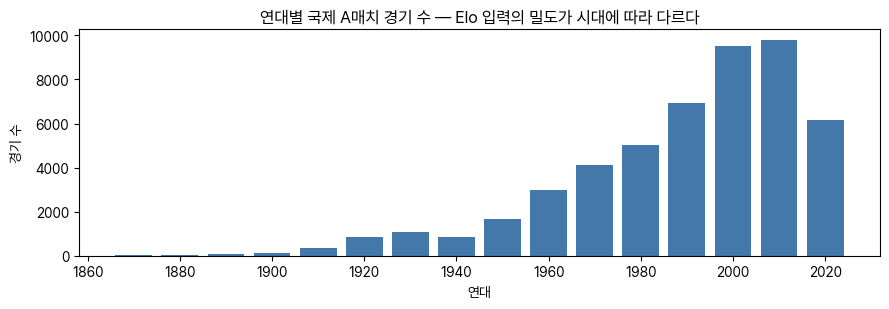

저장: notebooks\figures\00_results_density.png


In [9]:
res = tables["results"].copy()
res["date"] = pd.to_datetime(res["date"])
res["decade"] = (res["date"].dt.year // 10) * 10

print(f"results 기간: {res['date'].min().date()} ~ {res['date'].max().date()} ({len(res):,}경기)")
print(f"참가 팀 수(홈∪원정): {len(set(res['home_team']) | set(res['away_team']))}")
print("\n대회 구성 상위 8종:")
print(res["tournament"].value_counts().head(8).to_string())

# 이상값 후보: 최다 득점 경기 — 데이터 오류인가, 역사적 사실인가
top_score = res.loc[(res["home_score"] + res["away_score"]).idxmax()]
print(f"\n최다 득점 경기: {top_score['date'].date()} {top_score['home_team']} "
      f"{top_score['home_score']:.0f}-{top_score['away_score']:.0f} {top_score['away_team']} "
      f"({top_score['tournament']})")
print("→ 2001 호주-아메리칸사모아 31-0은 FIFA 공인 국제 A매치 최다 득점 기록(실제 사실) — 오류 아님")

decade_counts = res.groupby("decade").size()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(decade_counts.index, decade_counts.values, width=8, color="#4477aa")
ax.set_title("연대별 국제 A매치 경기 수 — Elo 입력의 밀도가 시대에 따라 다르다")
ax.set_xlabel("연대"); ax.set_ylabel("경기 수")
plt.tight_layout(); plt.savefig(FIGURES / "00_results_density.png", dpi=120); plt.show()
print(f"저장: {(FIGURES / '00_results_density.png').relative_to(ROOT)}")

## 8. 팀명 정합 — martj42 ↔ jfjelstul (개정안 §6.5-2)

두 출처를 잇는 유일한 다리는 **팀 이름 문자열**입니다. martj42는 "현재 승계팀 이름"
원칙(예: 1954 서독 경기가 Germany로 기록)이고, jfjelstul은 당대 표기(West Germany)를
유지합니다. 매핑이 틀리면 Elo가 엉뚱한 팀에 적립되므로, **미매핑 팀을 표로 전수
산출**하고 수동 매핑으로 해소합니다 — 조용한 드롭 금지.

In [10]:
# 대상은 남자 대회 팀만 — martj42는 남자 A매치 한정이므로 여자 대회 Elo는 기존
# 방식(월드컵 경기 한정)을 유지한다 (ADR-007: 주 학습은 남자 대회)
m_mens = tables["matches"][tables["matches"]["tournament_name"].str.contains("Men")]
jf_teams = set(m_mens["home_team_name"]) | set(m_mens["away_team_name"])
mj_teams = set(res["home_team"]) | set(res["away_team"])

unmatched_before = sorted(jf_teams - mj_teams)
print(f"jfjelstul 남자 월드컵 출전 팀: {len(jf_teams)}개 / martj42 등장 팀: {len(mj_teams)}개")
print(f"직접 일치하지 않는 팀 (매핑 필요): {len(unmatched_before)}개")
print(unmatched_before)

# 수동 매핑 — 실측(첫 실행의 미해소 목록)으로 확정한 6건.
# martj42는 승계팀이 있으면 현재 이름(서독→Germany), 승계가 없으면 당대 팀을
# 별도로 유지한다(동독=German DR 298경기). Czechoslovakia·Yugoslavia·China PR은
# martj42가 당대 표기를 그대로 써서 직접 일치했다 — 매핑 불필요.
TEAM_MAP = {
    "West Germany": "Germany",          # 1990 통일 — FIFA 기록 승계
    "East Germany": "German DR",        # 승계 없음 — martj42 별도 팀 유지 (실측 298경기)
    "Soviet Union": "Russia",           # FIFA 승계 인정
    "Serbia and Montenegro": "Serbia",  # FIFA 승계 인정
    "Zaire": "DR Congo",                # 국명 변경 (1997)
    "Dutch East Indies": "Indonesia",   # 국명 변경 (1938 월드컵 출전)
}
applied = {k: v for k, v in TEAM_MAP.items() if k in unmatched_before and v in mj_teams}
unmatched_after = sorted(set(unmatched_before) - set(applied))

map_df = pd.DataFrame(
    [{"jfjelstul 표기": k, "martj42 표기": v, "상태": "매핑"} for k, v in applied.items()]
    + [{"jfjelstul 표기": t, "martj42 표기": "—", "상태": "미해소"} for t in unmatched_after]
)
print(f"\n매핑 적용: {len(applied)}건 / 잔여 미해소: {len(unmatched_after)}건")
map_df

jfjelstul 남자 월드컵 출전 팀: 85개 / martj42 등장 팀: 337개
직접 일치하지 않는 팀 (매핑 필요): 6개
['Dutch East Indies', 'East Germany', 'Serbia and Montenegro', 'Soviet Union', 'West Germany', 'Zaire']

매핑 적용: 6건 / 잔여 미해소: 0건


,jfjelstul 표기,martj42 표기,상태
0,West Germany,Germany,매핑
1,East Germany,German DR,매핑
2,Soviet Union,Russia,매핑
3,Serbia and Montenegro,Serbia,매핑
4,Zaire,DR Congo,매핑
5,Dutch East Indies,Indonesia,매핑


In [11]:
# 매핑표를 interim에 저장 — 02장 Elo 산출이 이 표를 읽는다 (경로 계약)
map_out = pd.DataFrame([{"jfjelstul": k, "martj42": v} for k, v in applied.items()])
map_out.to_parquet(DATA_INTERIM / "team_name_map.parquet")
print(f"저장: data/interim/team_name_map.parquet ({len(map_out)}건)")

# 게이트: 미해소 팀이 남으면 그 사실을 숨기지 않고 명시적으로 실패시킨다
if unmatched_after:
    print(f"⚠️ 미해소 {len(unmatched_after)}건 — 02장 Elo 확장 전 반드시 해소 필요: {unmatched_after}")
assert len(unmatched_after) == 0, f"팀명 미해소 {len(unmatched_after)}건 — 조용한 드롭 금지"
print("팀명 정합 게이트 통과 — 월드컵 출전 전 팀이 martj42와 연결됨")

저장: data/interim/team_name_map.parquet (6건)
팀명 정합 게이트 통과 — 월드컵 출전 전 팀이 martj42와 연결됨


## 9. 이 장의 답

**"데이터는 어떻게 확보했고, 그 실체는 무엇인가"**

1. **수집** — 2개 출처를 커밋 핀·SHA-256 체크섬으로 고정 수집 (§1 대장). 1차
   jfjelstul(CC BY-SA 4.0, P2→P10 감사 통과)은 월드컵 경기·대회·득점의 정본,
   2차 martj42(CC0)는 Elo 입력 확장용 전체 A매치. 실명 파일(goalscorers)은
   다운로드 자체를 하지 않음
2. **마스킹 경계** — 실명 컬럼은 로드 직후 구조적으로 제거되어 interim에는 존재하지
   않음 (NB-R1, 01장에서 이동). 이후 전 장은 `data/interim/`만 읽는다
3. **실체 확인 (실측)** — 조인 키 유일성·pandera 계약·FK 정합 전부 통과.
   **결측은 양 핵심 테이블 모두 0** (matches 0/37 · results 0/9 — 결측 처리
   부담 없음). (date,대진) 중복 2행은 1974 타히티 더블헤더(실제 역사)로 유지.
   최다 득점 31-0(2001 호주-아메리칸사모아)도 역사적 사실 — 오류 아님
4. **두 출처의 다리** — 남자 월드컵 출전 85팀 전부를 martj42와 연결 (수동 매핑
   6건: 서독→Germany, 동독→German DR 등). 매핑표를 `team_name_map.parquet`로
   저장 (02장 Elo 확장의 입력 계약)

**01·02장에 넘기는 결정 과제**:
1. ⚠️ **results가 2026-07-19까지 — 2026 월드컵 본선 경기 포함.** 02장 Elo 산출
   시 학습/검증/테스트 분할 경계 이전 경기만 쓰도록 컷오프 필수 (리키지 —
   평가_설계 §3의 확장 입력 적용)
2. 남녀 대회 분리 기준 재확인 (martj42는 남자 한정 — 여자 Elo는 기존 방식 유지)
3. 승부차기·연장의 라벨 처리(90분 기준) 재확인

In [12]:
# 01장으로의 인계 요약 (실측값)
print("=== 00장 산출물 인계 ===")
for p in sorted(DATA_INTERIM.glob("*.parquet")):
    print(f"  {p.relative_to(ROOT)} ({p.stat().st_size:,} bytes)")
print(f"figures: 00_missing_matches.png, 00_missing_results.png, 00_results_density.png")
print(f"다음 장 게이트: 01장은 data/interim/ 만 읽는다 (raw 접근 금지)")

=== 00장 산출물 인계 ===
  data\interim\jfjelstul_goals.parquet (136,357 bytes)
  data\interim\jfjelstul_matches.parquet (76,945 bytes)
  data\interim\jfjelstul_team_appearances.parquet (96,833 bytes)
  data\interim\jfjelstul_tournaments.parquet (13,121 bytes)
  data\interim\martj42_results.parquet (488,540 bytes)
  data\interim\team_name_map.parquet (2,266 bytes)
figures: 00_missing_matches.png, 00_missing_results.png, 00_results_density.png
다음 장 게이트: 01장은 data/interim/ 만 읽는다 (raw 접근 금지)
